In [73]:
# @title 👤 ToolGuard-AI: Face Detection & Registration Dashboard {display-mode: "form"}

import os
import sys
import json
import shutil
import cv2
import numpy as np
from google.colab import drive, files, output
from IPython.display import HTML, display, clear_output

# --- 1. GOOGLE DRIVE SETUP ---
def setup_drive():
    base_path = '/content/drive/MyDrive/ToolGuard-AI/'
    if not os.path.exists('/content/drive'):
        print("Mounting Google Drive...")
        drive.mount('/content/drive')

    dirs = [
        'ai/face',
        'models/face_detection',
        'face/registered',
        'face/verification/input',
        'face/verification/results',
        'face/results',
        'notebooks/face_detection',
        'training/face_detection',
        'logs/face_detection'
    ]

    for d in dirs:
        os.makedirs(os.path.join(base_path, d), exist_ok=True)

    # Create __init__.py
    init_file = os.path.join(base_path, 'ai/face/__init__.py')
    if not os.path.exists(init_file):
        with open(init_file, 'w') as f:
            pass

    print(f"\nProject structure verified at: {base_path}")
    return base_path

# --- 2. INSTALLATION ---
def install_dependencies():
    print("Installing dependencies (this may take a minute)...")
    !pip install -q -U deepface retina-face opencv-python

    import pkg_resources
    import deepface
    # Note: retina-face installs as 'retinaface'
    import retinaface

    print("-" * 30)
    print(f"Python version: {sys.version.split()[0]}")
    print(f"DeepFace version: {pkg_resources.get_distribution('deepface').version}")
    print(f"RetinaFace version: {pkg_resources.get_distribution('retina-face').version}")
    print(f"OpenCV version: {cv2.__version__}")
    print("-" * 30)

# --- 3. CORE LOGIC ---
def detect_faces(image_path, base_path):
    from deepface import DeepFace
    try:
        detections = DeepFace.extract_faces(
            img_path=image_path,
            detector_backend='retinaface',
            enforce_detection=False,
            align=True
        )

        results = {"faces_detected": 0, "faces": []}
        img = cv2.imread(image_path)

        if detections:
            for det in detections:
                conf = det.get('confidence', 0.0)
                area = det['facial_area']

                results["faces"].append({
                    "confidence": float(conf),
                    "bbox": {"x": area['x'], "y": area['y'], "w": area['w'], "h": area['h']}
                })
                cv2.rectangle(img, (area['x'], area['y']), (area['x']+area['w'], area['y']+area['h']), (0, 255, 0), 2)

            results["faces_detected"] = len(results["faces"])
            filename = os.path.basename(image_path)
            save_path = os.path.join(base_path, 'face/results', f"annotated_{filename}")
            cv2.imwrite(save_path, img)

        return results
    except Exception as e:
        print(f"Detection Error: {e}")
        return {"faces_detected": 0, "faces": []}

# --- 4. INTERACTIVE INTERFACE ---
def run_registration(base_path):
    print("\n=== INTERACTIVE PERSON REGISTRATION ===")
    user_input = input("Enter number of persons to register (default 1): ")
    num_persons = int(user_input) if user_input.isdigit() else 1

    for i in range(num_persons):
        print(f"\nPerson {i+1}")
        name = input("Enter name: ").strip()

        success = False
        while not success:
            print(f"Upload face image for {name}:")
            uploaded = files.upload()
            if not uploaded:
                continue

            temp_filename = list(uploaded.keys())[0]
            report = detect_faces(temp_filename, base_path)
            count = report['faces_detected']

            if count == 0:
                print("❌ No face detected. Try again.")
            elif count > 1:
                print(f"❌ {count} faces detected. Upload single-face image.")
            else:
                person_id = f"person_{str(i+1).zfill(3)}"
                target_dir = os.path.join(base_path, 'face/registered', person_id)
                os.makedirs(target_dir, exist_ok=True)

                with open(os.path.join(target_dir, 'name.txt'), 'w') as f:
                    f.write(name)

                shutil.move(temp_filename, os.path.join(target_dir, 'registration.jpg'))
                print(f"✅ {name} registered.")
                success = True

# --- EXECUTION ---
def main():
    base = setup_drive()
    install_dependencies()
    run_registration(base)

if __name__ == "__main__":
    main()


Project structure verified at: /content/drive/MyDrive/ToolGuard-AI/
Installing dependencies (this may take a minute)...
------------------------------
Python version: 3.12.13
DeepFace version: 0.0.100
RetinaFace version: 0.0.18
OpenCV version: 5.0.0
------------------------------

=== INTERACTIVE PERSON REGISTRATION ===
Enter number of persons to register (default 1): 2

Person 1
Enter name: dax
Upload face image for dax:


Saving dax2.jpg to dax2.jpg
✅ dax registered.

Person 2
Enter name: meet
Upload face image for meet:


Saving meet photo2.jpg to meet photo2.jpg
✅ meet registered.



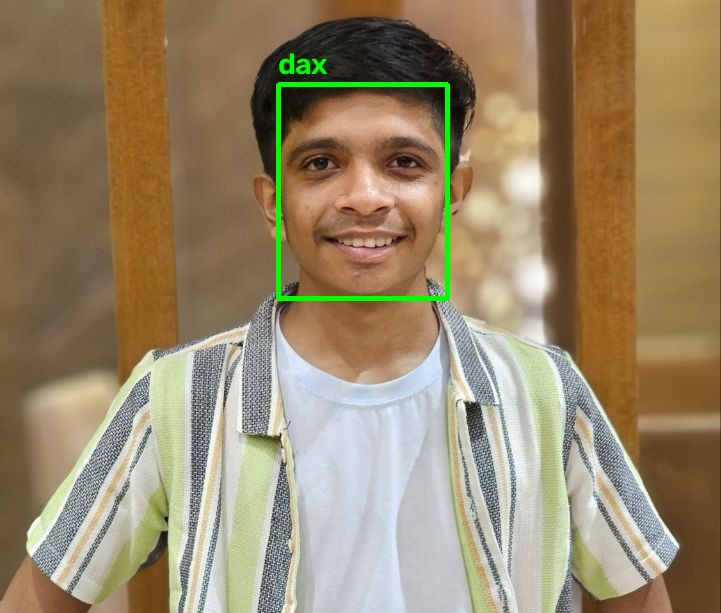

In [75]:
# @title 🔍 ToolGuard-AI: Face Verification Dashboard {display-mode: "form"}

import os
import json
import cv2
import numpy as np
from google.colab import files, output
from IPython.display import HTML, display
from deepface import DeepFace
import base64

# --- 1. CONFIGURATION ---
BASE_PATH = '/content/drive/MyDrive/ToolGuard-AI/'
REGISTERED_DIR = os.path.join(BASE_PATH, 'face/registered')
VERIFY_INPUT_DIR = os.path.join(BASE_PATH, 'face/verification/input')

# --- 2. CORE VERIFICATION LOGIC ---
def verify_identity(input_image_path):
    """
    Performs 1:N verification against the registered database.
    """
    results = {
        "detected": False,
        "match_found": False,
        "identity": "Unknown",
        "confidence": 0.0,
        "image_base64": ""
    }

    try:
        # 1. Detect and Align
        face_objs = DeepFace.extract_faces(
            img_path=input_image_path,
            detector_backend='retinaface',
            enforce_detection=False
        )

        if not face_objs or face_objs[0]['confidence'] < 0.8:
            return results

        results["detected"] = True

        # 2. Iterate through registered persons
        best_score = float('inf')
        identified_name = "Unknown"

        for person_id in sorted(os.listdir(REGISTERED_DIR)):
            reg_path = os.path.join(REGISTERED_DIR, person_id, 'registration.jpg')
            name_path = os.path.join(REGISTERED_DIR, person_id, 'name.txt')

            if not os.path.exists(reg_path): continue

            # Verification check
            result = DeepFace.verify(
                img1_path=input_image_path,
                img2_path=reg_path,
                model_name="VGG-Face",
                detector_backend="retinaface",
                distance_metric="cosine",
                enforce_detection=False
            )

            if result["verified"] and result["distance"] < best_score:
                best_score = result["distance"]
                with open(name_path, 'r') as f: identified_name = f.read().strip()
                results["match_found"] = True
                results["identity"] = identified_name
                results["confidence"] = round((1 - best_score) * 100, 2)

        # Prepare annotated image
        img = cv2.imread(input_image_path)
        area = face_objs[0]['facial_area']
        color = (0, 255, 0) if results["match_found"] else (0, 0, 255)
        cv2.rectangle(img, (area['x'], area['y']), (area['x']+area['w'], area['y']+area['h']), color, 4)
        cv2.putText(img, results["identity"], (area['x'], area['y']-10), cv2.FONT_HERSHEY_SIMPLEX, 1, color, 2)

        _, buffer = cv2.imencode('.jpg', img)
        results["image_base64"] = base64.b64encode(buffer).decode('utf-8')

        return results
    except Exception as e:
        print(f"Verification Error: {e}")
        return results

# --- 3. DASHBOARD RENDERER ---
def render_dashboard(data=None):
    kpi_detected = "YES" if data and data['detected'] else "NO"
    kpi_identity = data['identity'] if data else "Waiting..."
    kpi_conf = f"{data['confidence']}%" if data and data['match_found'] else "N/A"

    html_content = """
    <!DOCTYPE html>
    <html>
    <head>
        <script src="https://cdn.jsdelivr.net/npm/chart.js"></script>
        <style>
            body { font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; background-color: #f4f6f8; margin: 0; padding: 20px; color: #333; }
            .dashboard-container { display: grid; grid-template-columns: repeat(4, 1fr); grid-gap: 20px; }
            .card { background: white; border-radius: 12px; padding: 20px; box-shadow: 0 4px 6px rgba(0,0,0,0.05); }
            .kpi-card { text-align: center; }
            .kpi-value { font-size: 2.5em; font-weight: bold; margin: 10px 0; color: #2c3e50; }
            .kpi-label { font-size: 0.9em; color: #7f8c8d; text-transform: uppercase; letter-spacing: 1px; }
            .wide-card { grid-column: span 3; }
            .compact-card { grid-column: span 1; }
            .image-viewer { width: 100%; border-radius: 8px; border: 2px solid #ecf0f1; }
            .btn-upload { background: #3498db; color: white; border: none; padding: 12px 24px; border-radius: 6px; cursor: pointer; font-size: 16px; margin-bottom: 20px; transition: 0.3s; }
            .btn-upload:hover { background: #2980b9; }
            .status-tag { display: inline-block; padding: 4px 12px; border-radius: 20px; font-weight: bold; }
            .status-match { background: #e8f6ef; color: #27ae60; }
            .status-fail { background: #fdf2f2; color: #e74c3c; }
        </style>
    </head>
    <body>
        <button class="btn-upload" onclick="startVerification()">🚀 Upload Image to Verify</button>

        <div class="dashboard-container">
            <div class="card kpi-card">
                <div class="kpi-label">Face Detected</div>
                <div class="kpi-value">KPI_DETECTED</div>
            </div>
            <div class="card kpi-card">
                <div class="kpi-label">Identity</div>
                <div class="kpi-value">KPI_IDENTITY</div>
            </div>
            <div class="card kpi-card">
                <div class="kpi-label">Match Confidence</div>
                <div class="kpi-value">KPI_CONF</div>
            </div>
            <div class="card kpi-card">
                <div class="kpi-label">Database Size</div>
                <div class="kpi-value">DB_SIZE</div>
            </div>

            <div class="card wide-card">
                <h3>Verification Result Visualization</h3>
                <div class="canvas-wrapper" style="position: relative; min-height: 400px;">
                    <img id="resultImage" src="IMAGE_SRC" class="image-viewer" style="display: IMAGE_DISPLAY">
                </div>
            </div>

            <div class="card compact-card">
                <h3>System Status</h3>
                <p><strong>Backend:</strong> DeepFace / RetinaFace</p>
                <p><strong>Metric:</strong> Cosine Similarity</p>
                <hr>
                <p>Ensure images are well-lit and the person is facing the camera.</p>
            </div>
        </div>

        <script>
            function startVerification() {
                google.colab.kernel.invokeFunction('trigger_upload', [], {});
            }

            window.onerror = function(message) {
                google.colab.kernel.invokeFunction('report_js_error', [message], {});
            };
        </script>
    </body>
    </html>
    """

    db_size = len(os.listdir(REGISTERED_DIR))
    html_content = html_content.replace("KPI_DETECTED", kpi_detected)
    html_content = html_content.replace("KPI_IDENTITY", kpi_identity)
    html_content = html_content.replace("KPI_CONF", kpi_conf)
    html_content = html_content.replace("DB_SIZE", str(db_size))

    if data and data['image_base64']:
        html_content = html_content.replace("IMAGE_SRC", f"data:image/jpeg;base64,{data['image_base64']}")
        html_content = html_content.replace("IMAGE_DISPLAY", "block")
    else:
        html_content = html_content.replace("IMAGE_SRC", "")
        html_content = html_content.replace("IMAGE_DISPLAY", "none")

    display(HTML(html_content))

# --- 4. CALLBACKS ---
def trigger_upload():
    uploaded = files.upload()
    if uploaded:
        fname = list(uploaded.keys())[0]
        input_path = os.path.join(VERIFY_INPUT_DIR, fname)
        os.makedirs(VERIFY_INPUT_DIR, exist_ok=True)
        with open(input_path, 'wb') as f: f.write(uploaded[fname])

        clear_output(wait=True)
        results = verify_identity(input_path)
        render_dashboard(results)

def _report_js_error(message):
    print(f"JS Error: {message}")

output.register_callback('trigger_upload', trigger_upload)
output.register_callback('report_js_error', _report_js_error)

# Initial Render
render_dashboard()